# Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step2:Load Dataset

In [29]:
df=pd.read_csv("Cardiotocographic.csv")
df

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


# Step3: Dataset Information

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [31]:
df.shape

(2126, 14)

# Step4: Check the Missing Values

In [32]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [33]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [34]:
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

# Step5: Check the Duplicate Records

In [35]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows: 2


In [36]:
df.shape

(2124, 14)

# Check the Datatype

In [37]:
df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

# Statistical Summary
## Step 7: Descriptive Statistics

In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LB,2124.0,133.342039,11.212396,51.842487,126.000000,133.000000,140.000000,214.000000
AC,2124.0,0.003220,0.004371,-0.019284,0.000000,0.001668,0.005612,0.038567
FM,2124.0,0.009904,0.067571,-0.480634,0.000000,0.000000,0.002568,0.961268
UC,2124.0,0.004394,0.003340,-0.014925,0.001858,0.004486,0.006536,0.030002
DL,2124.0,0.001897,0.003344,-0.015393,0.000000,0.000000,0.003292,0.030769
DS,2124.0,0.000003,0.000141,-0.001353,0.000000,0.000000,0.000000,0.002706
DP,2124.0,0.000175,0.000836,-0.005348,0.000000,0.000000,0.000000,0.010695
ASTV,2124.0,47.012459,18.812403,-63.000000,32.000000,49.000000,61.000000,162.000000
MSTV,2124.0,1.364345,1.174084,-6.600000,0.700000,1.200000,1.700000,13.800000
ALTV,2124.0,10.295650,21.212676,-91.000000,0.000000,0.000000,11.000000,182.000000


# Step8: Mean,Median,Standard Deviation and IQR

In [39]:
summary = pd.DataFrame({
    "Mean":df.mean(numeric_only=True),
    "Median":df.median(numeric_only=True),
    "Std":df.std(numeric_only=True),
    "Q1":df.quantile(0.25,numeric_only=True),
    "Q3":df.quantile(0.75,numeric_only=True)
})

summary["IQR"] = summary["Q3"]-summary["Q1"]

summary

,Mean,Median,Std,Q1,Q3,IQR
LB,133.342039,133.000000,11.212396,126.000000,140.000000,14.000000
AC,0.003220,0.001668,0.004371,0.000000,0.005612,0.005612
FM,0.009904,0.000000,0.067571,0.000000,0.002568,0.002568
UC,0.004394,0.004486,0.003340,0.001858,0.006536,0.004678
DL,0.001897,0.000000,0.003344,0.000000,0.003292,0.003292
DS,0.000003,0.000000,0.000141,0.000000,0.000000,0.000000
DP,0.000175,0.000000,0.000836,0.000000,0.000000,0.000000
ASTV,47.012459,49.000000,18.812403,32.000000,61.000000,29.000000
MSTV,1.364345,1.200000,1.174084,0.700000,1.700000,1.000000
ALTV,10.295650,0.000000,21.212676,0.000000,11.000000,11.000000


# Outlier Detection
## Step9: Boxplot

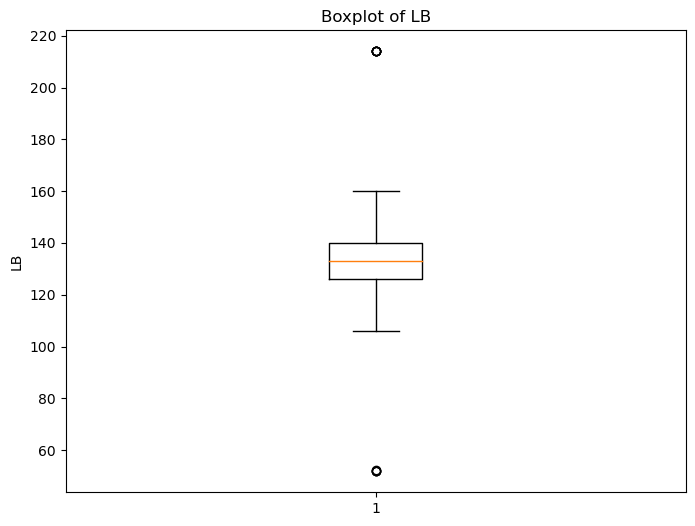

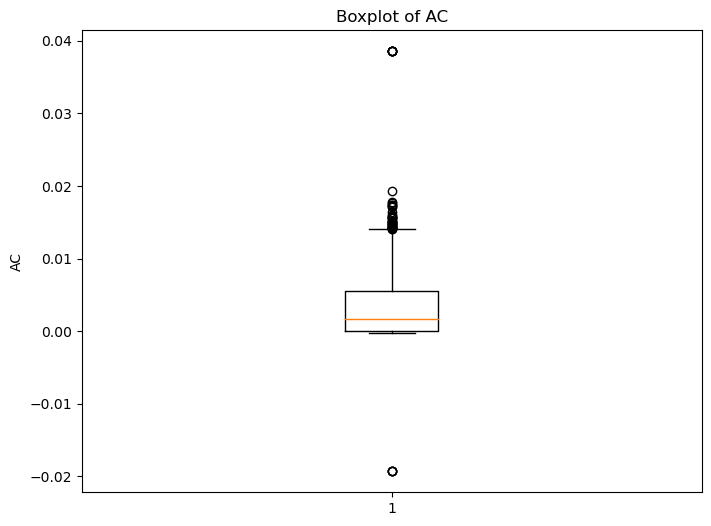

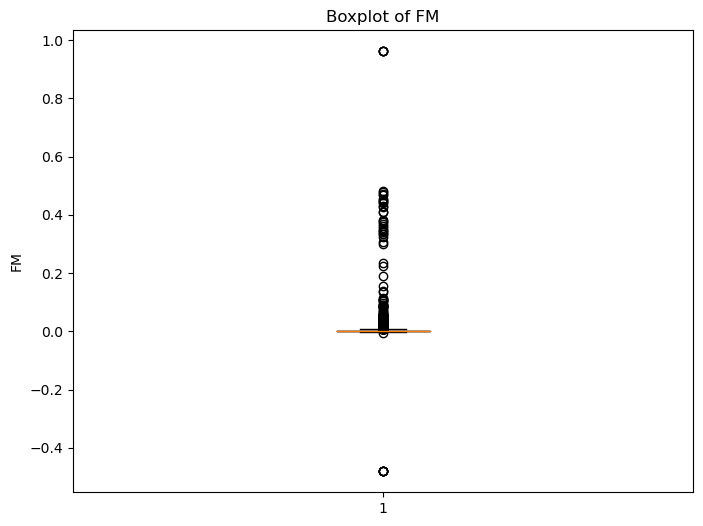

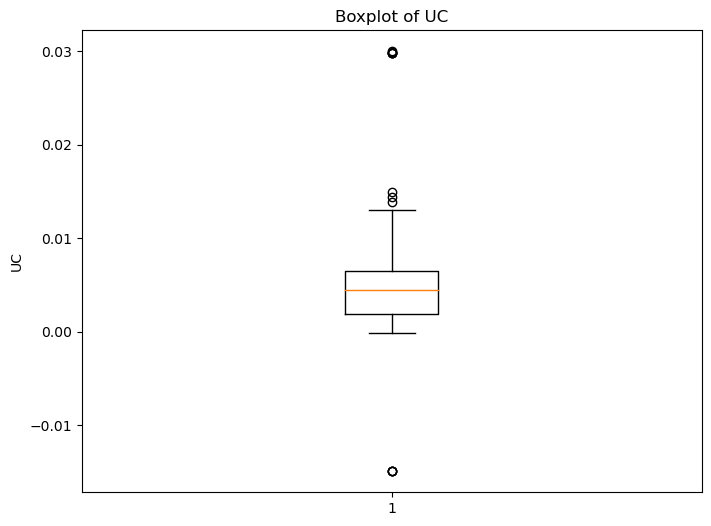

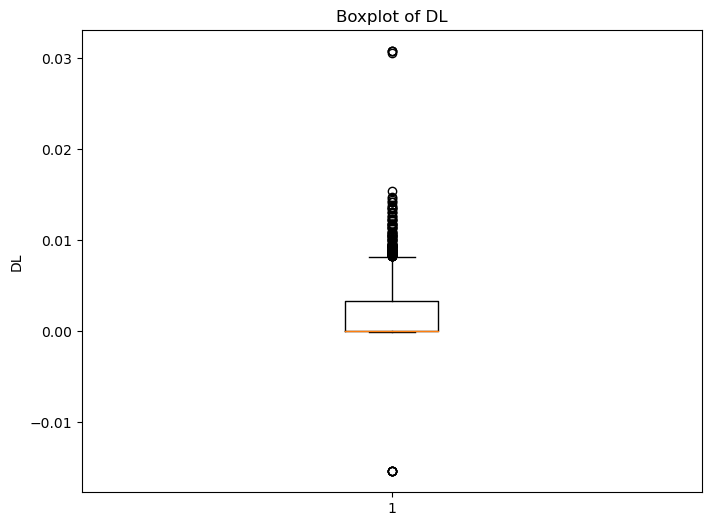

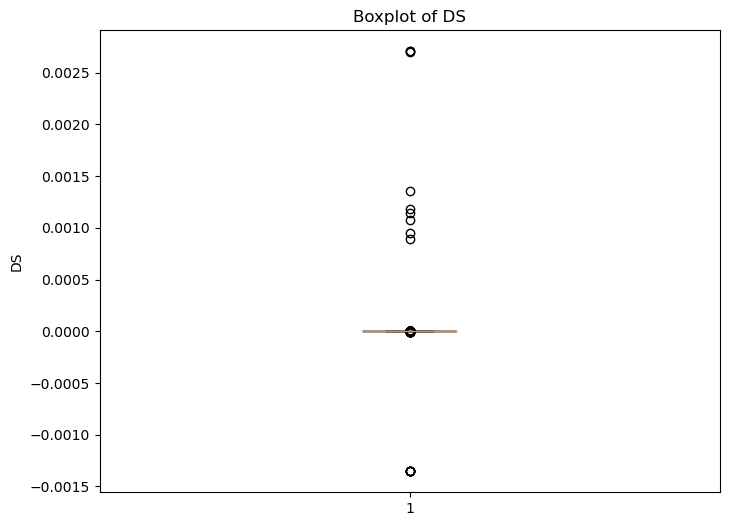

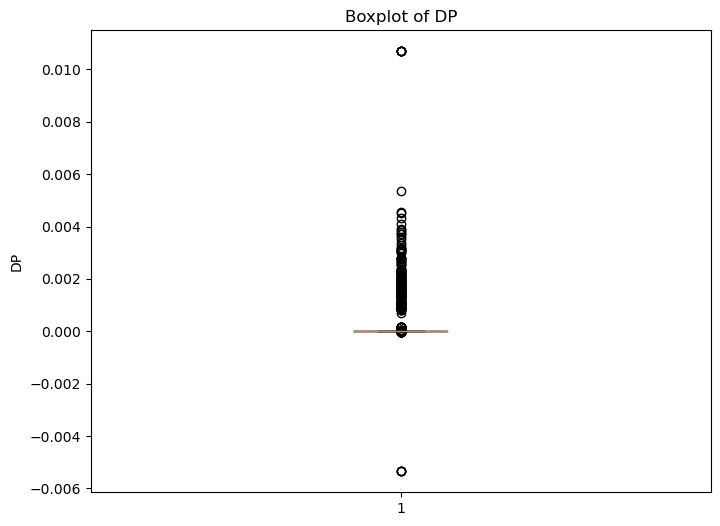

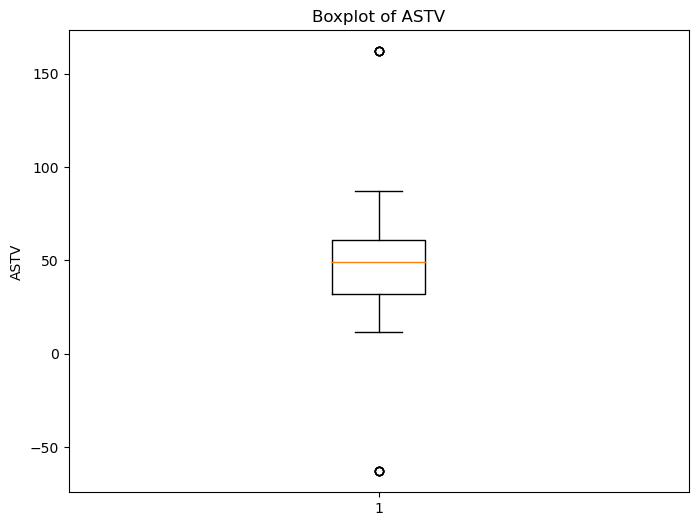

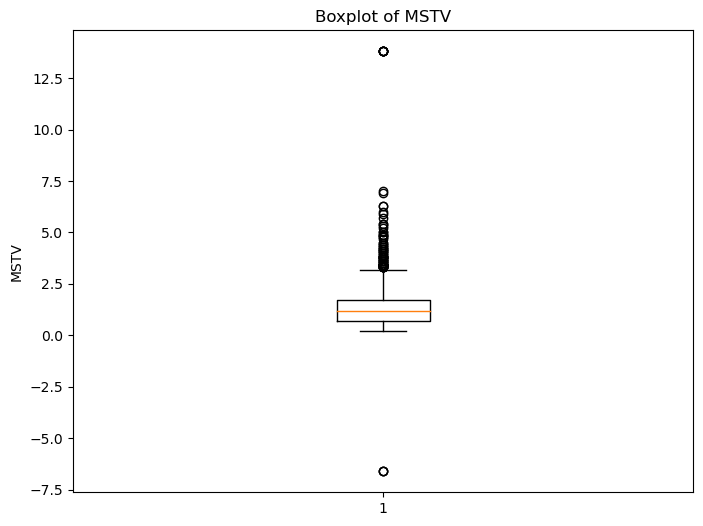

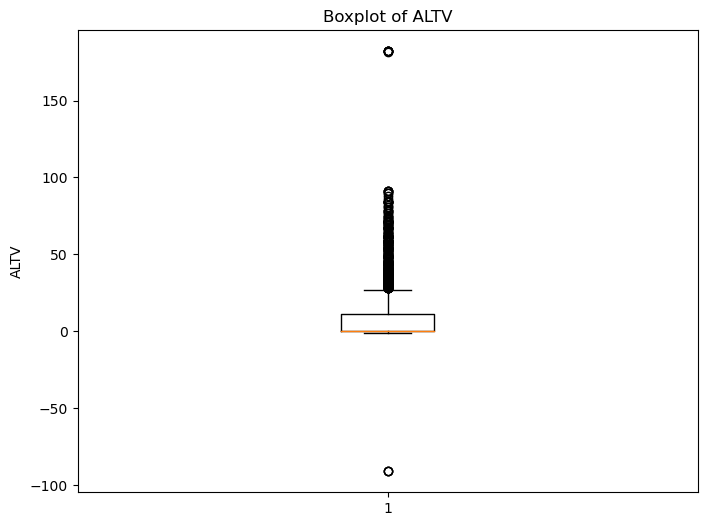

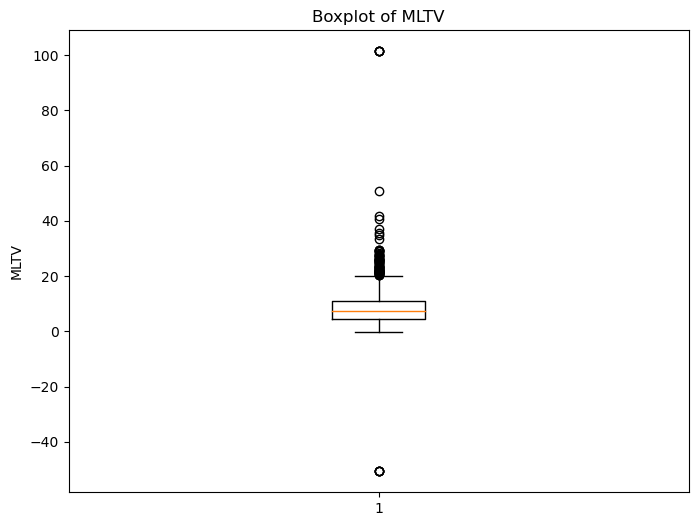

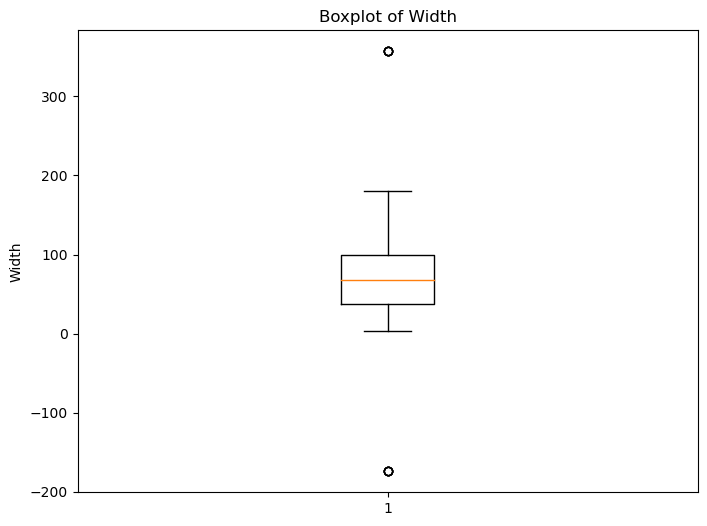

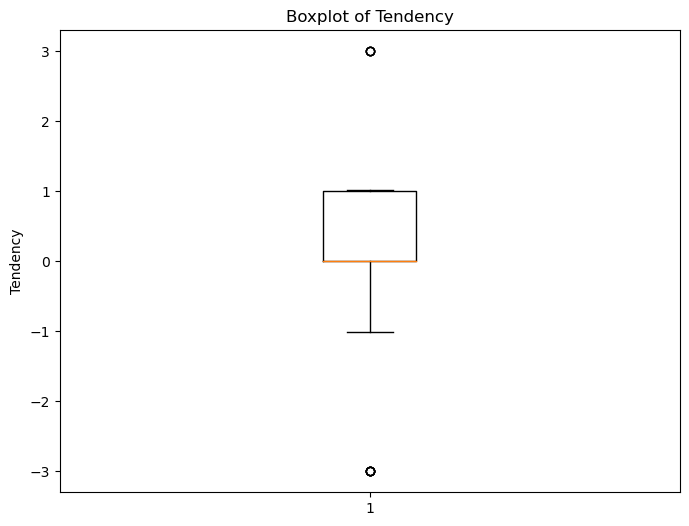

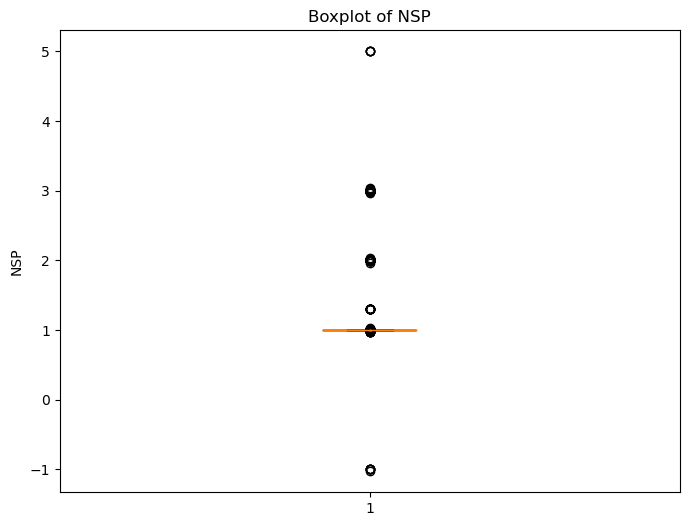

In [44]:
for col in df:
    plt.figure(figsize=(8,6))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

# Removing Outliers Using IQR

In [45]:
for col in df:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    df[col]=df[col].clip(lower,upper)
df

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,27.5,2.4,64.0,0.999926,1.0
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,20.1,117.0,1.000000,1.0
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.006421,0.007426,0.000000,0.0,0.0,79.0,0.2,25.0,7.2,40.0,0.000000,1.0
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.0,7.1,66.0,1.000000,1.0
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.0,6.1,67.0,1.000000,1.0
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.0,7.0,66.0,1.000000,1.0


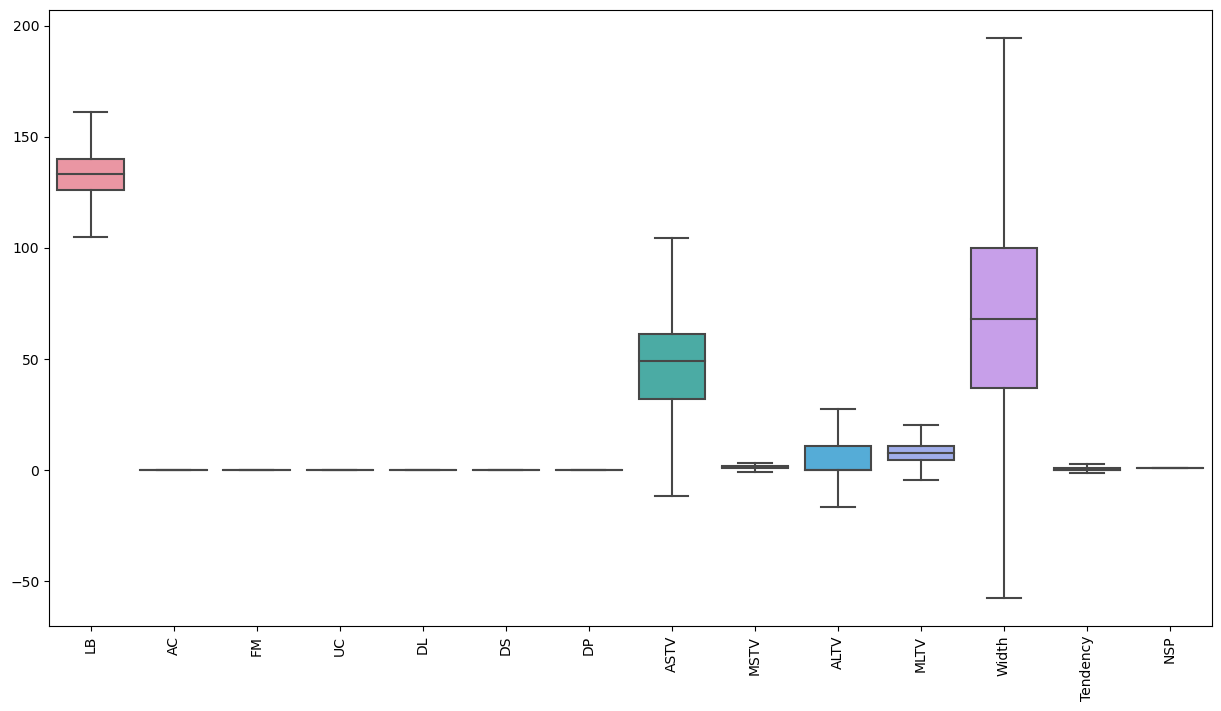

In [47]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

# Data Visualization
## Histogram

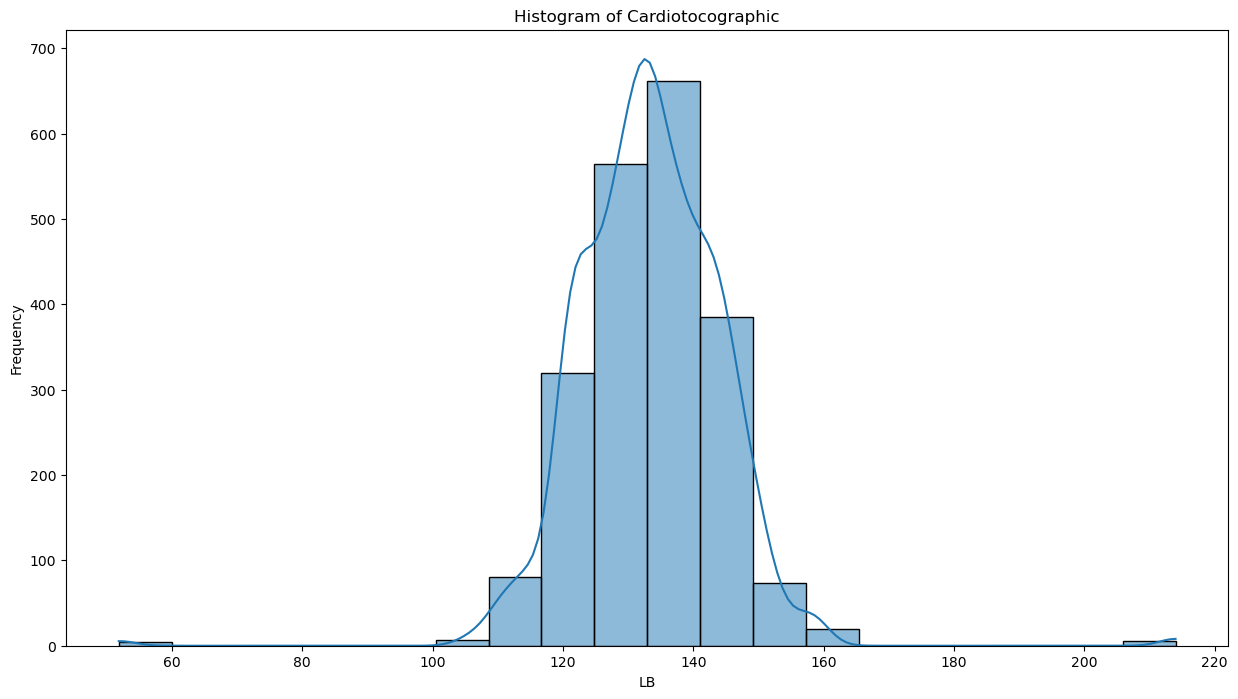

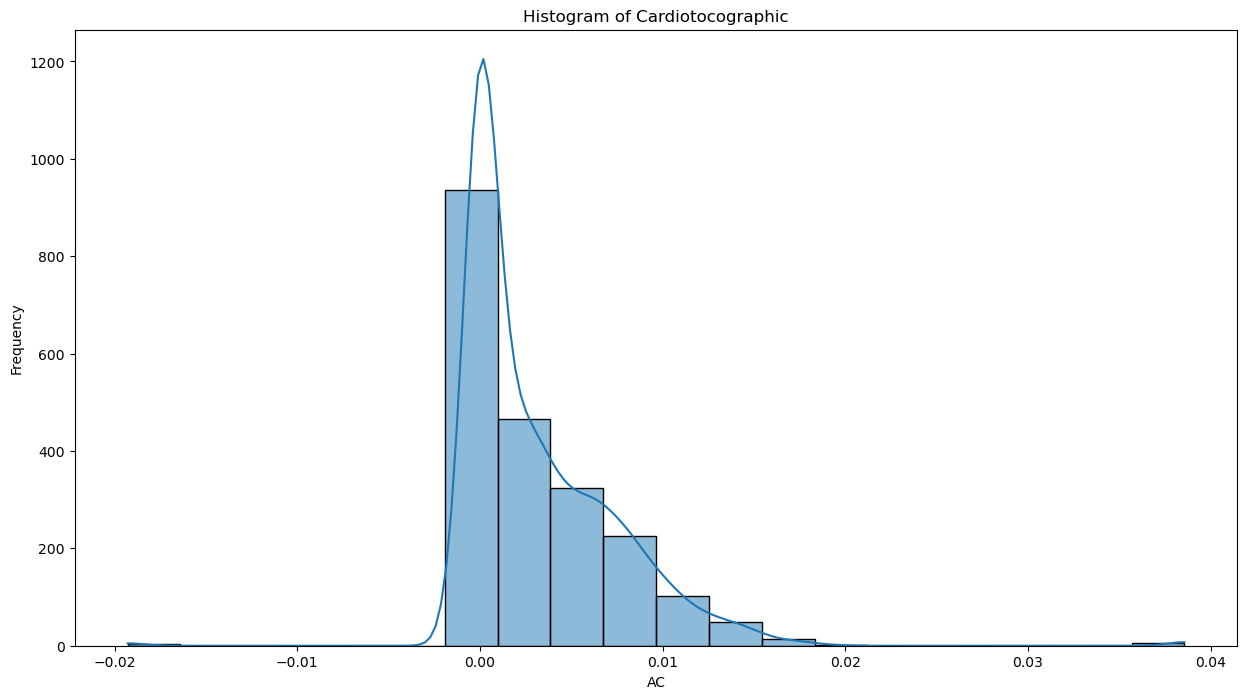

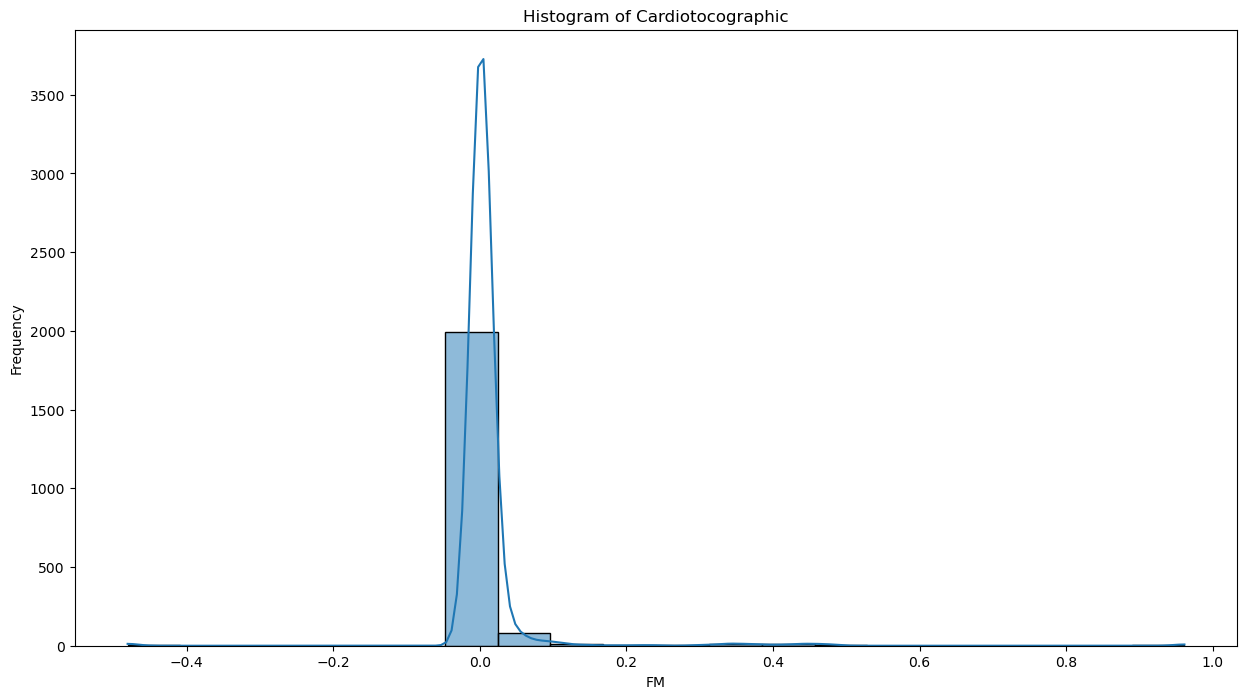

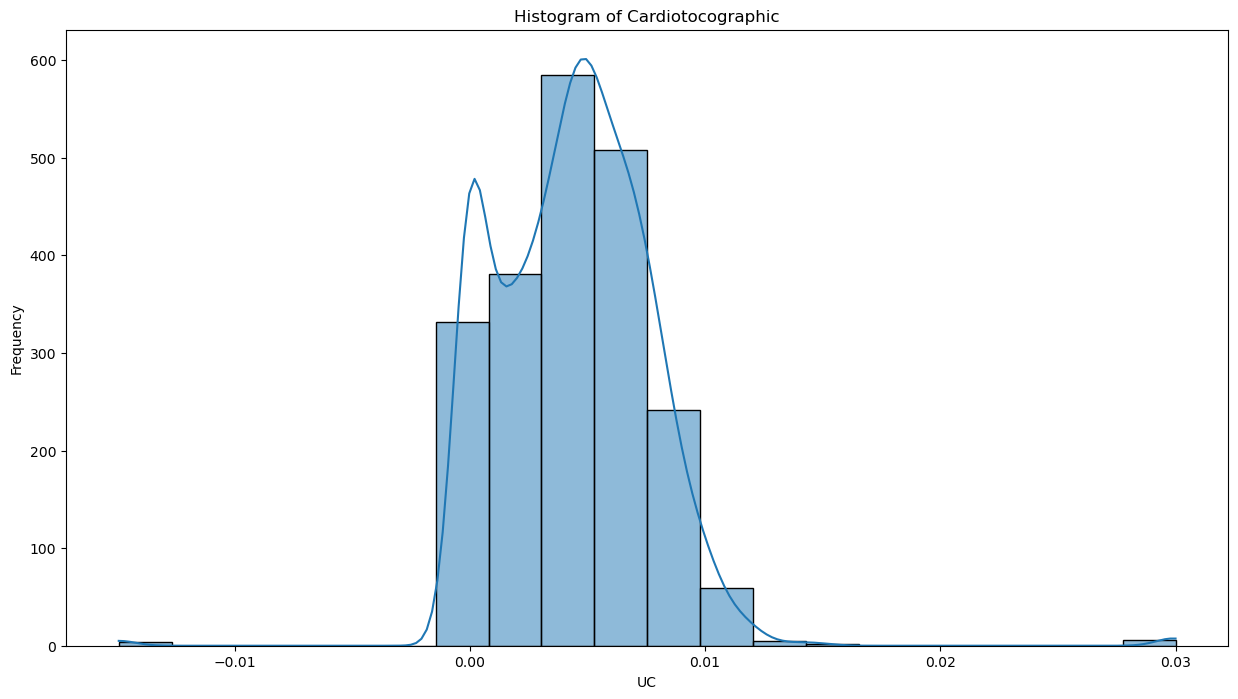

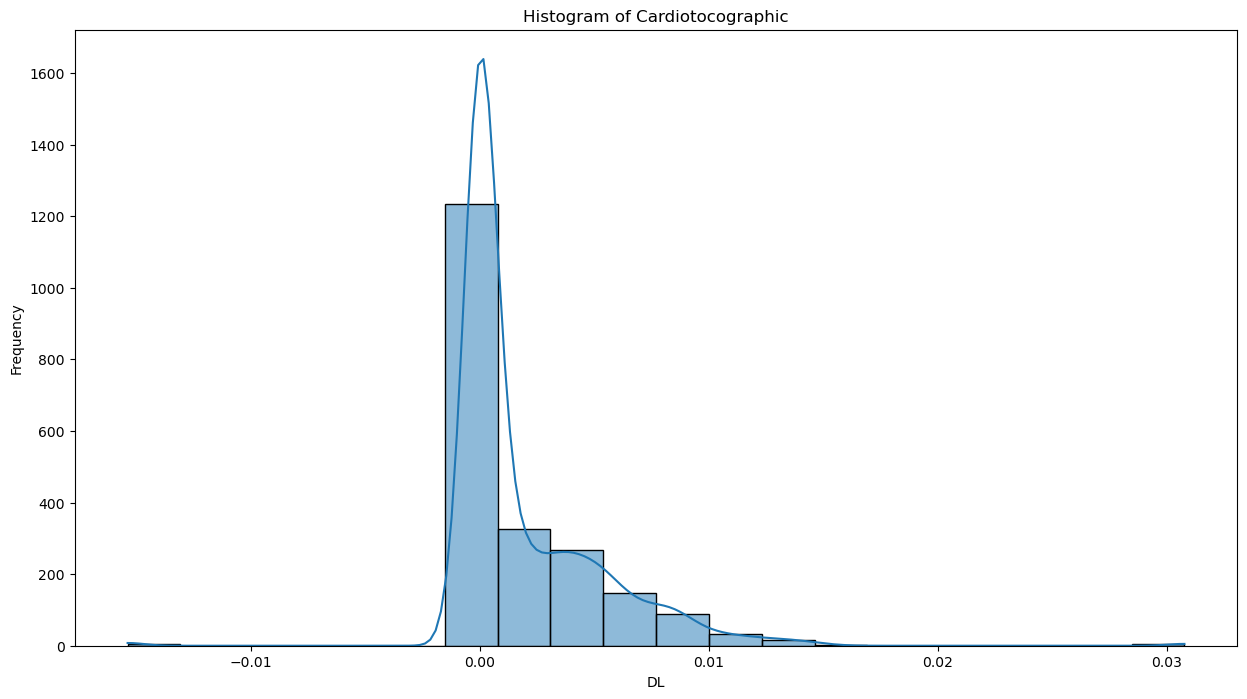

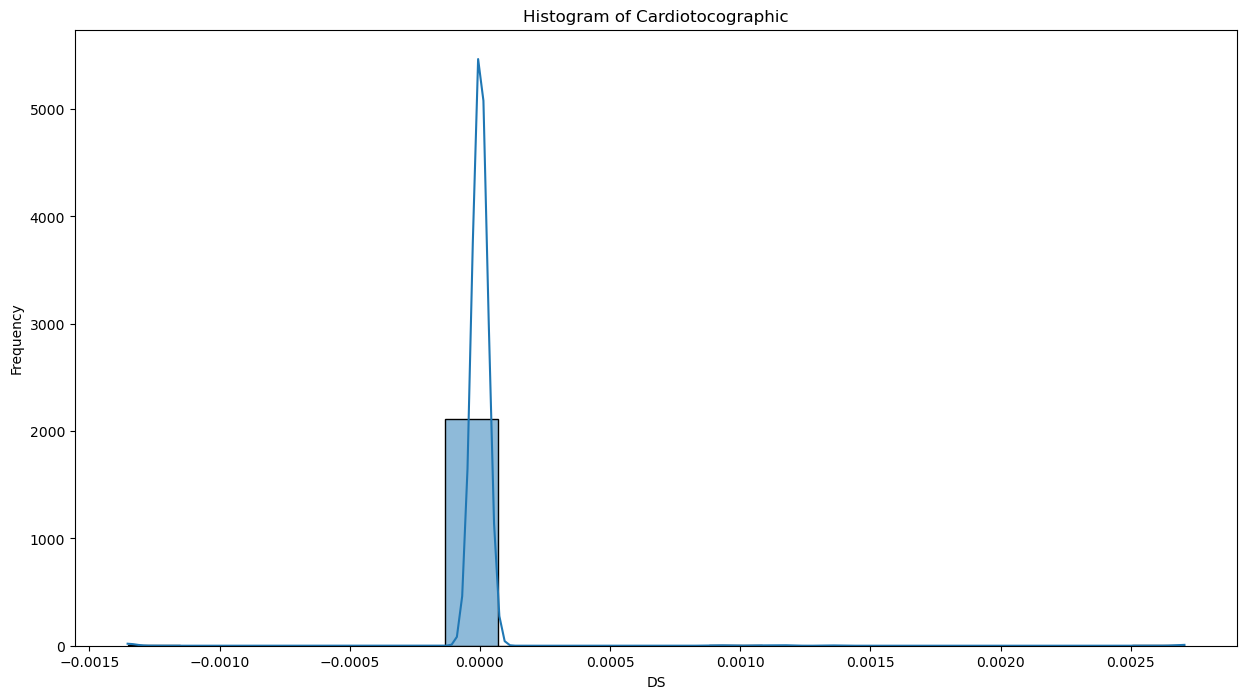

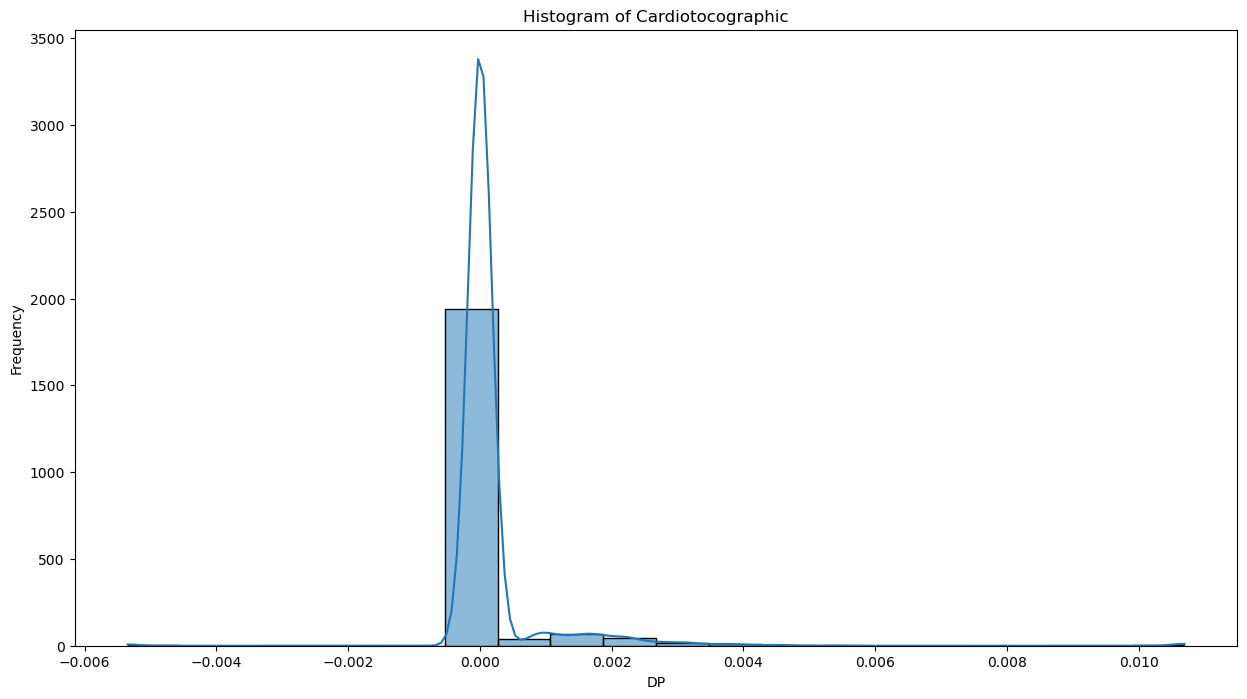

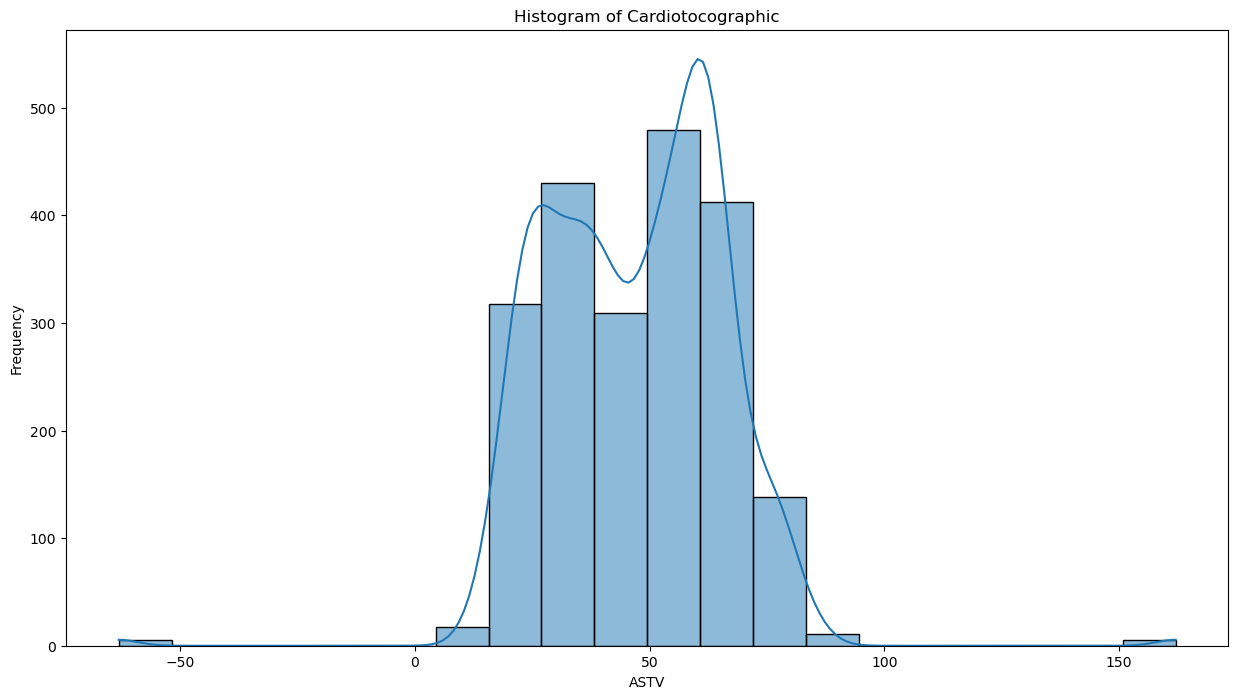

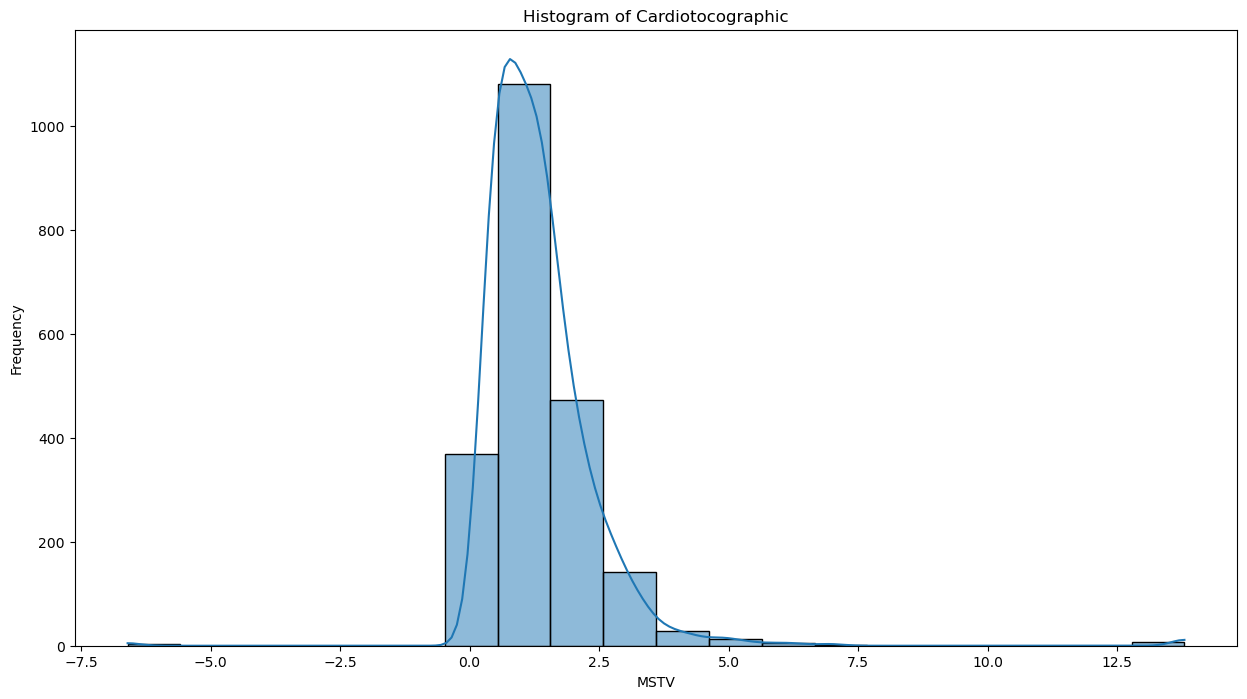

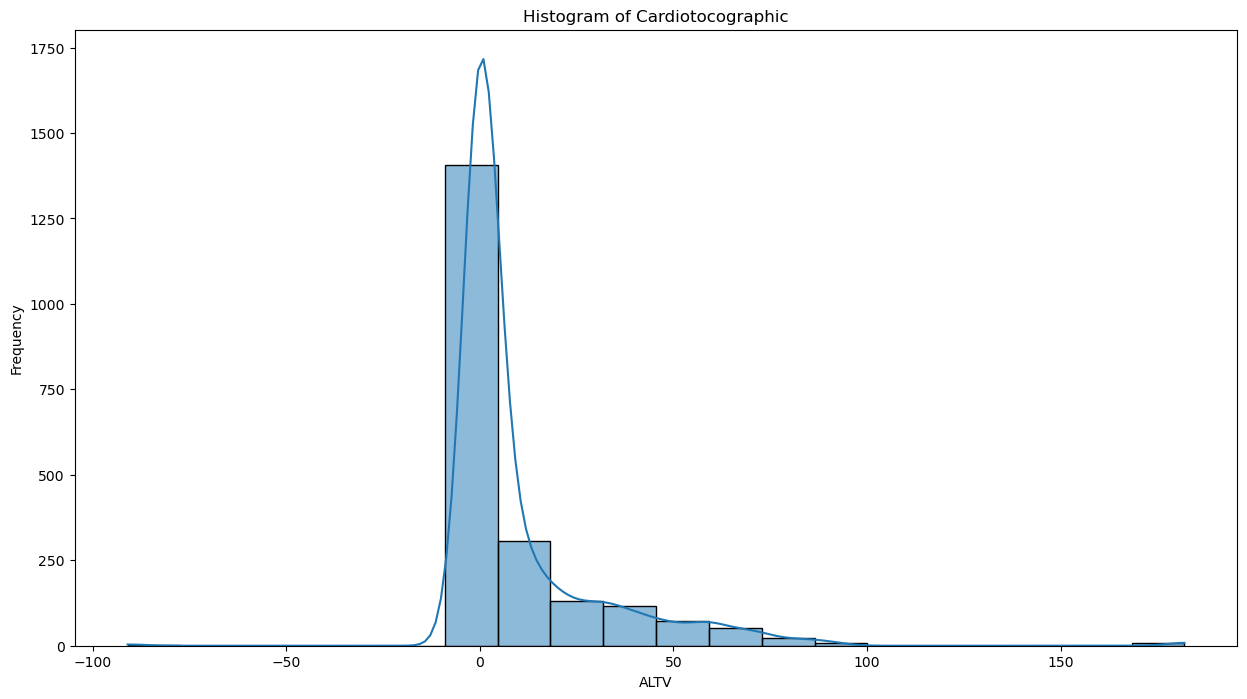

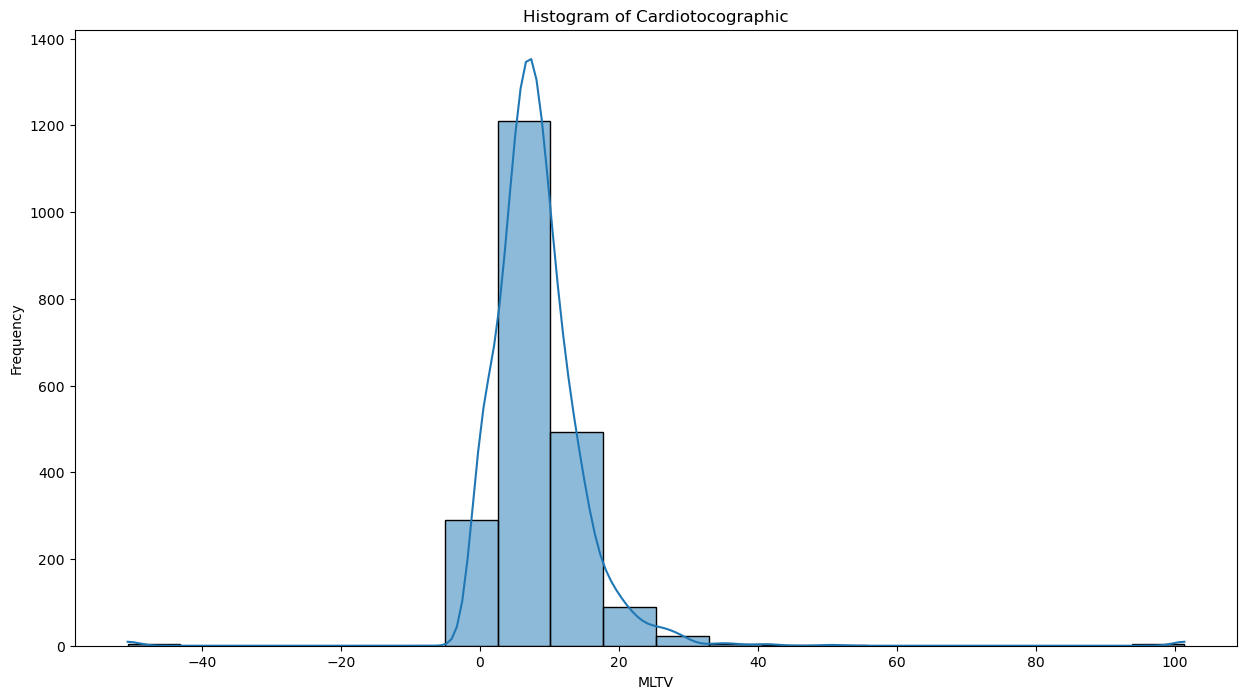

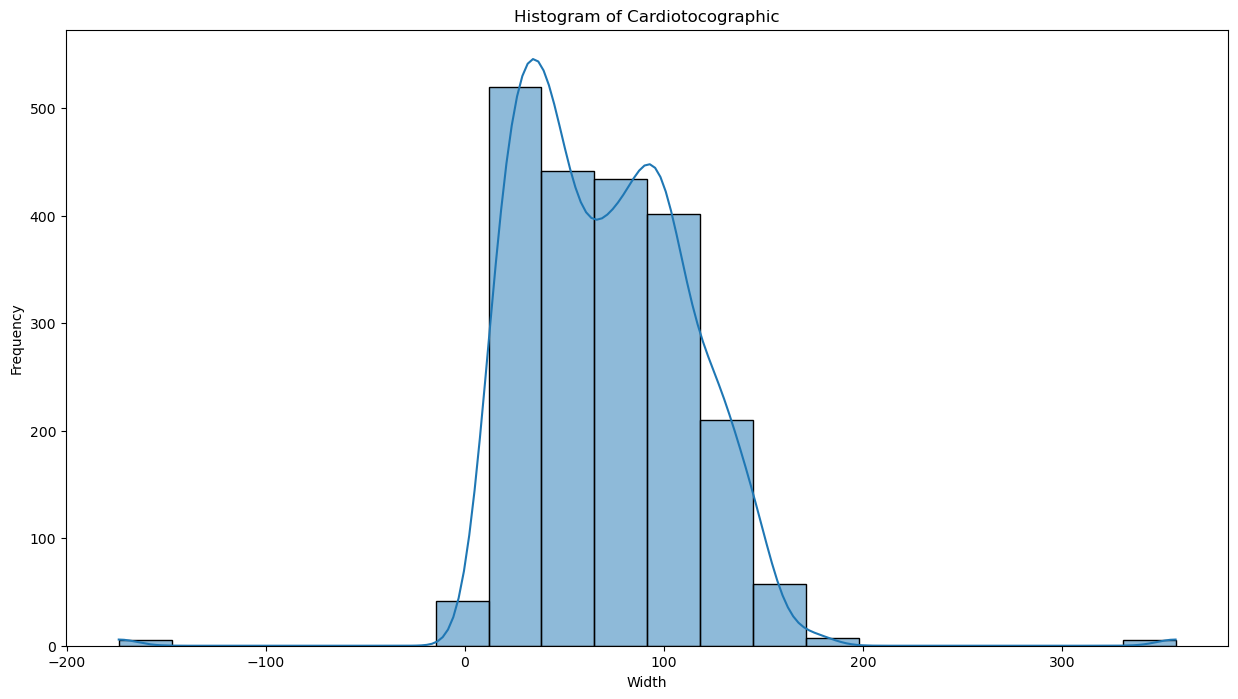

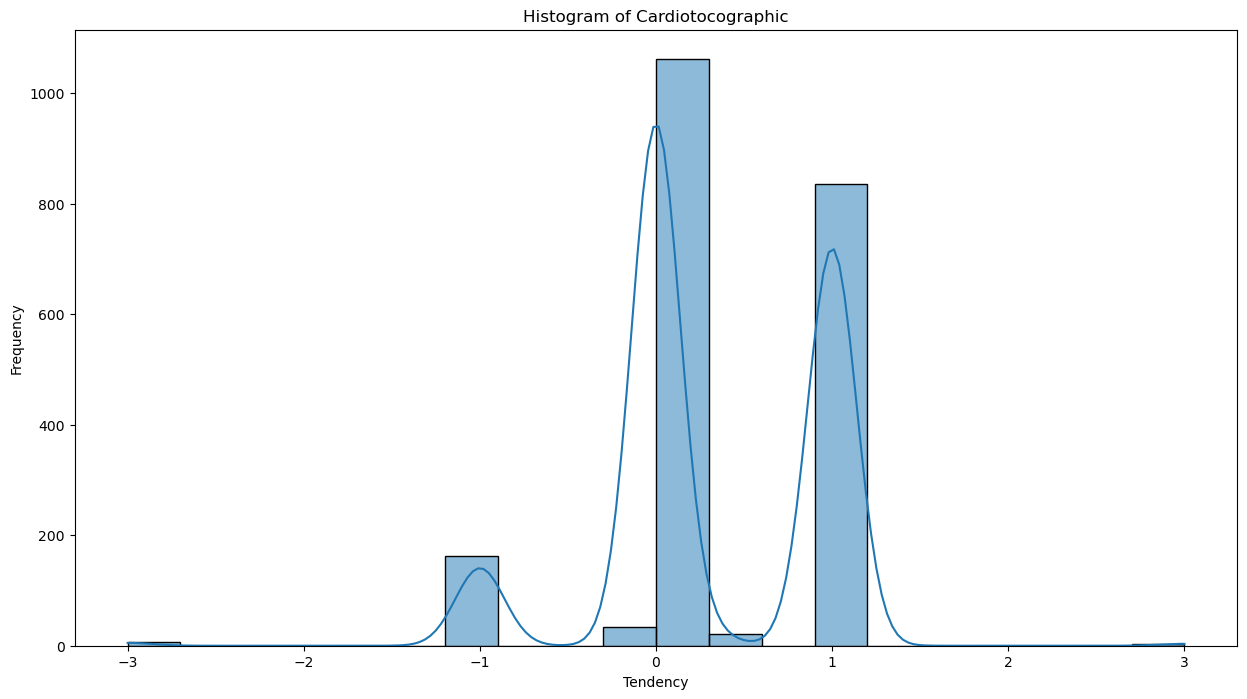

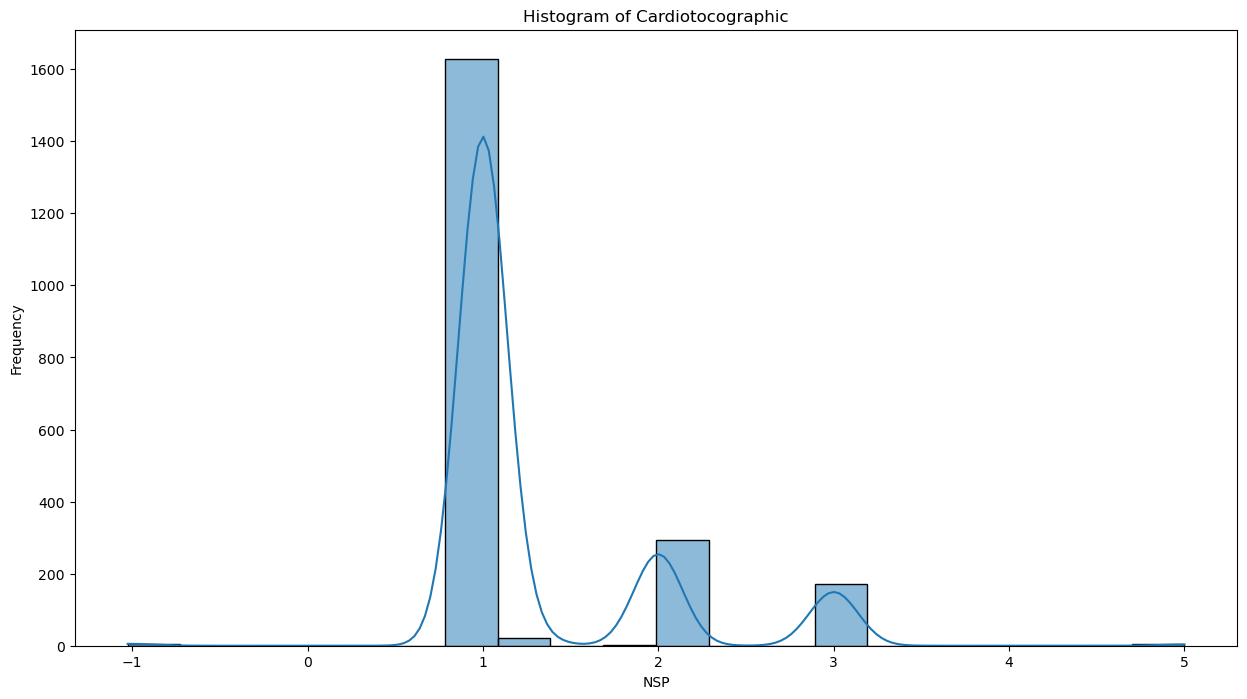

In [25]:
for col in df:
    plt.figure(figsize=(15,8))
    sns.histplot(data=df,x=col,bins=20,kde=True)
    plt.title("Histogram of Cardiotocographic")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# HeatMap

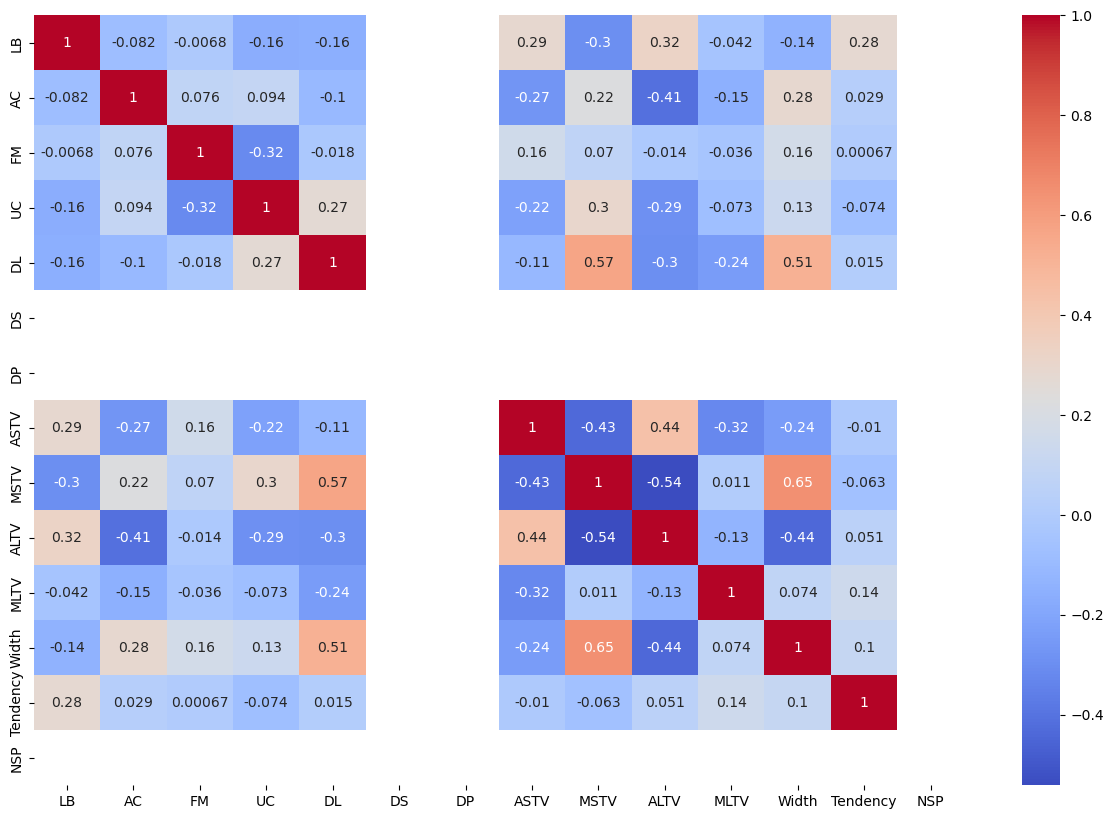

In [51]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

# ScatterPlot

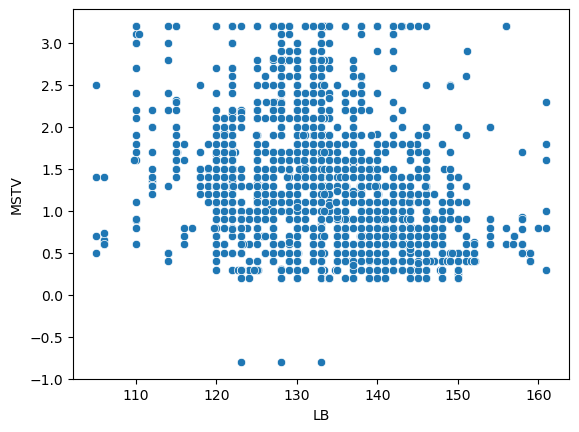

In [52]:
sns.scatterplot(x="LB",y="MSTV",data=df)
plt.show()

# PairPlot

C:\Users\maddi\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


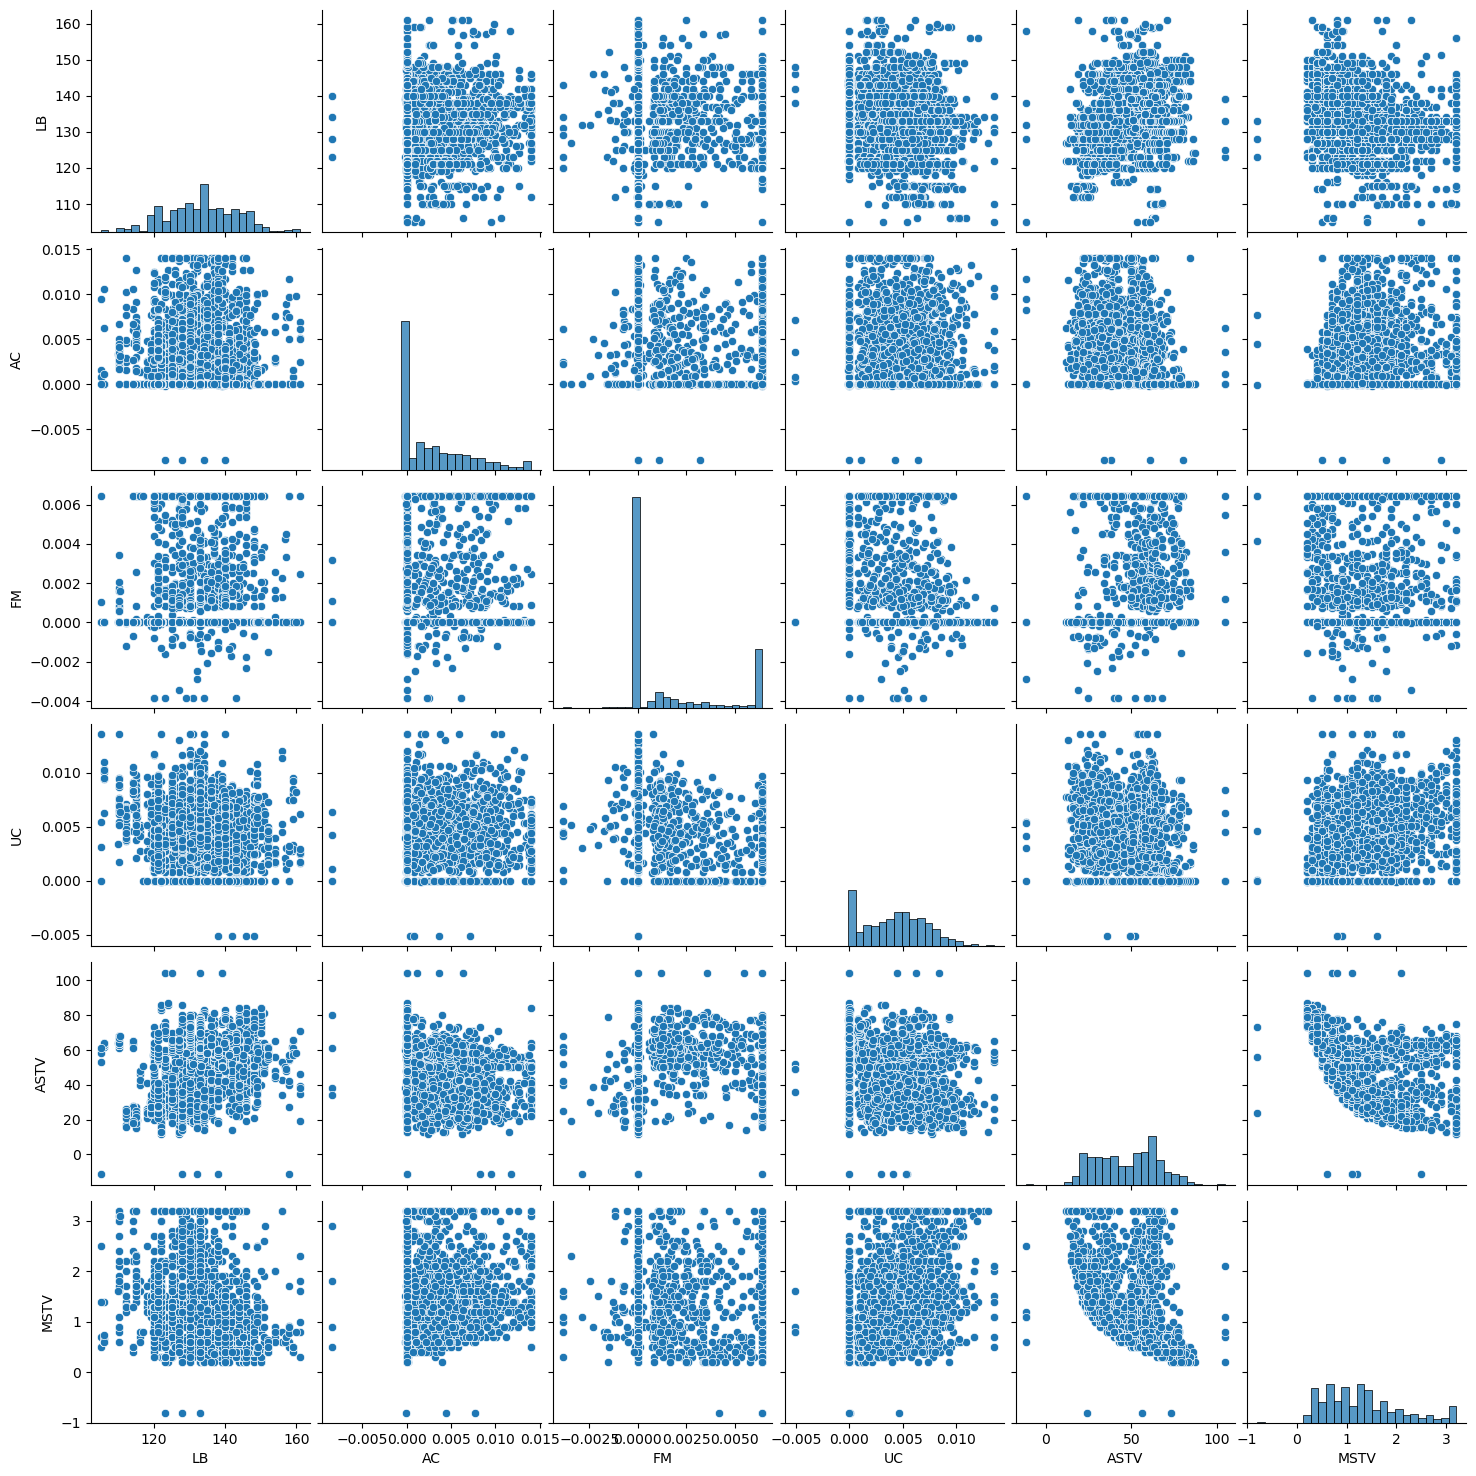

In [53]:
sns.pairplot(df[['LB','AC','FM','UC','ASTV','MSTV']])

plt.show()

# Violinplot

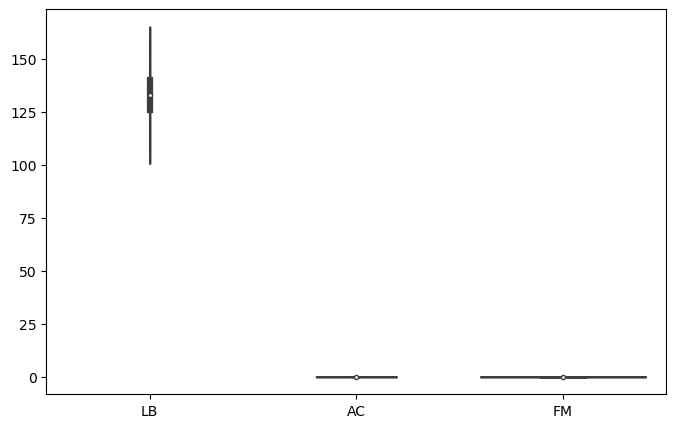

In [54]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df[['LB','AC','FM']])
plt.show()

# Pattern Recognization
## Correlation Matrix

In [57]:
corr=df.corr(numeric_only=True)

corr

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.081669,-0.006815,-0.163308,-0.156278,NaN,NaN,0.285463,-0.295017,0.322748,-0.042275,-0.140008,0.281361,NaN
AC,-0.081669,1.000000,0.076091,0.093575,-0.102934,NaN,NaN,-0.273178,0.217933,-0.409829,-0.152032,0.283771,0.029333,NaN
FM,-0.006815,0.076091,1.000000,-0.318156,-0.018024,NaN,NaN,0.155798,0.070412,-0.013820,-0.036313,0.164247,0.000673,NaN
UC,-0.163308,0.093575,-0.318156,1.000000,0.268151,NaN,NaN,-0.217484,0.298462,-0.294226,-0.072964,0.131110,-0.074266,NaN
DL,-0.156278,-0.102934,-0.018024,0.268151,1.000000,NaN,NaN,-0.112289,0.566625,-0.296383,-0.242173,0.514348,0.014583,NaN
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASTV,0.285463,-0.273178,0.155798,-0.217484,-0.112289,NaN,NaN,1.000000,-0.433731,0.438800,-0.323958,-0.242124,-0.010278,NaN
MSTV,-0.295017,0.217933,0.070412,0.298462,0.566625,NaN,NaN,-0.433731,1.000000,-0.541296,0.011322,0.646468,-0.063075,NaN
ALTV,0.322748,-0.409829,-0.013820,-0.294226,-0.296383,NaN,NaN,0.438800,-0.541296,1.000000,-0.133185,-0.439913,0.050549,NaN


In [58]:
corr_pairs=corr.unstack()

corr_pairs.sort_values(ascending=False)

LB     LB          1.0
AC     AC          1.0
Width  Width       1.0
MLTV   MLTV        1.0
ALTV   ALTV        1.0
                  ... 
NSP    ALTV        NaN
       MLTV        NaN
       Width       NaN
       Tendency    NaN
       NSP         NaN
Length: 196, dtype: float64

**Exploratory Data Analysis (EDA) Report**

**1. Objective**

The objective of this analysis was to explore the dataset, understand the characteristics of the variables, identify data quality issues such as missing values and outliers, examine relationships among variables, and derive meaningful insights that can support future predictive modeling and decision-making.

**2. Data Overview**

The dataset was successfully loaded into Python using Pandas.
Initial exploration was performed using head(), tail(), info(), describe(), and shape.
Both numerical and categorical features were identified.
The target variable was analyzed separately to understand its distribution.

**3. Data Preprocessing**

The following preprocessing steps were carried out:

Checked for missing values.
Removed or handled duplicate records.
Converted categorical variables into numerical format where necessary.
Scaled numerical features when required.
Examined outliers using box plots and treated them appropriately.

These preprocessing steps improved the quality of the dataset and made it suitable for further analysis and machine learning.

**4. Exploratory Data Analysis**

Several visualization techniques were used to understand the data:

Histograms were used to study feature distributions.
Box plots helped identify outliers.
Count plots showed the frequency of categorical variables.
Correlation heatmaps highlighted relationships between numerical variables.
Pair plots/scatter plots were used to examine interactions between important features.

The visualizations provided a better understanding of the underlying data patterns.

**5. Key Findings**

The dataset contained variables with different distributions.
Some numerical features exhibited skewness and outliers.
Several variables showed moderate to strong correlations.
The target variable distribution was examined to determine whether the dataset was balanced or imbalanced.
Feature relationships suggested that some variables are likely to be important predictors for future modeling.

**6. Insights**

Features with high correlation may contribute significantly to prediction.
Outliers can influence model performance and should be handled carefully.
Proper feature scaling is beneficial for distance-based and gradient-based algorithms.
Encoding categorical variables enables their use in machine learning models.

**7. Recommendations**

Perform feature selection to remove redundant variables.
Apply feature engineering to create additional informative features.
If the target variable is imbalanced, consider resampling techniques such as SMOTE or undersampling.
Compare multiple machine learning algorithms to identify the best-performing model.
Perform hyperparameter tuning to further improve model accuracy.
Validate the final model using cross-validation to ensure generalization.

**8. Conclusion**

The exploratory data analysis provided a comprehensive understanding of the dataset by identifying data quality issues, examining feature distributions, and revealing relationships among variables. The preprocessing and visualization steps prepared the data for predictive modeling. The insights obtained from this analysis can guide feature selection, model development, and future improvements to achieve better predictive performance.